# Instruction Fine Tuning GPT2 model with Alpaca dataset

Inspiration: https://github.com/rasbt/LLMs-from-scratch/blob/main/ch07/01_main-chapter-code/ch07.ipynb

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import requests
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
from functools import partial
from transformers import AutoTokenizer, AutoModelForCausalLM
import math
from helper_functions import calc_loss_loader, train_model_simple, plot_values
import time
import psutil
import itertools
from tqdm import tqdm

In [3]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
# Constants

PAD_TOKEN_ID = 50256
IGNORE_INDEX = -100
ALLOWED_MAX_LENGTH = 512
MODEL = "gpt2-medium"
NUM_WORKERS = 0
BATCH_SIZE = 4
LORA_RANK = 16
LORA_ALPHA = 32
EVALUATOR_MODEL = "llama3:latest"
OLLAMA_URL = "http://localhost:11435/api/chat"

## Download and format dataset

In [5]:
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

In [6]:
data = download_and_load_file("alpaca.json", "https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json")

In [7]:
print(type(data))
print(data[0])
print(data[20000])
print(data[-1])
print(len(data))

<class 'list'>
{'instruction': 'Give three tips for staying healthy.', 'input': '', 'output': '1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'}
{'instruction': 'Name the given musical note.', 'input': '(A musical note)', 'output': 'The musical note is an F sharp.'}
{'instruction': 'Analyze the given legal document and explain the key points.', 'input': 'The following is an excerpt from a contract between two parties, labeled "Company A" and "Company B": \n\n"Company A agrees to provide reasonable assistance to Company B in ensuring the accuracy of the financial statements it provides. This includes allowing Company A reasonable access to personnel and other documents which may be necessary for Company B’s review. Company B agrees to maintain the document provided by Company A in confidence, and will not disclose the information to

In [8]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [9]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):

        self.data = data

        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(
                full_text,
                truncation=True,
                max_length=ALLOWED_MAX_LENGTH
            ))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.encoded_texts)

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

## Batching the dataset

In [11]:
train_size = int(len(data)*0.85)
test_size = int(len(data)*0.10)
val_size = len(data) - train_size - test_size

torch.manual_seed(42)
train_subset, test_subset, val_subset = random_split(
    data, [train_size, test_size, val_size])

In [12]:
# Custom collate function to be used in DataLoader
# Pads the sequences to the smaller between the allowed_max_length
# and the batch_max_length.
# Replace pad_token_id with ignore_index from targets, leave only the first one
# It is done to avoid computing the loss on padding tokens
def custom_collate(
    batch,
    pad_token_id,
    ignore_index,
    allowed_max_length=None,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_list, targets_list = [], []
    
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index # leave the first pad_token_id (EOS) as is

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_list.append(inputs)
        targets_list.append(targets)

    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)

    return inputs_tensor, targets_tensor

In [13]:
if torch.cuda.is_available():
    device = torch.device("cuda")

print("Device:", device)
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 5070


## Create DataLoaders

In [14]:
custom_collate_fn = partial(
    custom_collate,
    pad_token_id=PAD_TOKEN_ID,
    ignore_index=IGNORE_INDEX,
    allowed_max_length=ALLOWED_MAX_LENGTH,
    device=device
)

In [15]:
train_dataset = InstructionDataset(train_subset, tokenizer)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=custom_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS
)
    
val_dataset = InstructionDataset(val_subset, tokenizer)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS
)

test_dataset = InstructionDataset(test_subset, tokenizer)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS
)

## Load a pre-trained LLM

In [16]:
model = AutoModelForCausalLM.from_pretrained(MODEL)

In [17]:
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3072, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=1024)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

Let's test the model, it won't be able to follow instructions since it's only been trained to generate text.

In [18]:
model.eval()

formatted_sample = format_input(data[0])
inputs = tokenizer(formatted_sample, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = outputs[0][inputs["input_ids"].shape[-1]:]
print(f"\n## Formated Sample: \n{formatted_sample}")
print(f"\n## Output: {tokenizer.decode(generated, skip_special_tokens=True)}")


## Formated Sample: 
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Give three tips for staying healthy.

## Output: 

### Response:

I'm not sure what the first tip is, but I'm going to give it anyway.

### Instruction:

I'm not sure what the second tip is, but I'm going to give it anyway.

### Response:

I'm not sure what the third tip is, but I'm going to give it anyway.

### Instruction:

I'm not sure what the fourth tip is, but I'm going to


## Apply LoRA

Replace attention and projection matrixes with LoRA matrixes with rank 16 and alpha 32

In [19]:
class LoraLayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, r, alpha):
        super().__init__()
        self.r = r
        self.alpha = alpha
        self.A = torch.nn.Parameter(torch.empty(in_dim, r))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = torch.nn.Parameter(torch.zeros(r, out_dim))

    def forward(self, x):
        return (self.alpha / self.r) * (x @ self.A @ self.B)

class LoraLinear(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        
        # Handle both nn.Linear and Conv1D
        if hasattr(linear, 'in_features'):
            in_dim  = linear.in_features
            out_dim = linear.out_features
        else:
            in_dim  = linear.nx
            out_dim = linear.nf
            
        self.lora = LoraLayer(in_dim, out_dim, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)
def replace_layers_with_lora(model, rank, alpha):
    for param in model.parameters():
        param.requires_grad = False

    for module in model.transformer.h:
        attn = module.attn
        attn.c_attn = LoraLinear(attn.c_attn, rank=rank, alpha=alpha)
        attn.c_proj = LoraLinear(attn.c_proj, rank=rank, alpha=alpha)

    return model

In [20]:
model = replace_layers_with_lora(model, rank=LORA_RANK, alpha=LORA_ALPHA)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Trainable: 2,359,296 / 357,182,464 (0.66%)


In [21]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): LoraLinear(
            (linear): Conv1D(nf=3072, nx=1024)
            (lora): LoraLayer()
          )
          (c_proj): LoraLinear(
            (linear): Conv1D(nf=1024, nx=1024)
            (lora): LoraLayer()
          )
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=4096, nx=1024)
          (c_proj): Conv1D(nf=1024, nx=4096)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,)

## Instruction fine-tune the LLM

In [22]:
model.to(device)

torch.manual_seed(42)
with torch.no_grad():
    train_loss = calc_loss_loader(train_dataloader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_dataloader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.2366333961486817
Validation loss: 2.9458503246307375


In [23]:
start_time = time.time()

torch.manual_seed(42)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_dataloader, val_dataloader, optimizer, device,
    num_epochs=num_epochs, eval_freq=200, eval_iter=5,
    start_context=format_input(val_subset[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 3.186, Val loss 2.907
Ep 1 (Step 000200): Train loss 1.558, Val loss 1.562
Ep 1 (Step 000400): Train loss 1.538, Val loss 1.519
Ep 1 (Step 000600): Train loss 1.503, Val loss 1.500
Ep 1 (Step 000800): Train loss 1.464, Val loss 1.488
Ep 1 (Step 001000): Train loss 1.511, Val loss 1.471
Ep 1 (Step 001200): Train loss 1.598, Val loss 1.471
Ep 1 (Step 001400): Train loss 1.514, Val loss 1.459
Ep 1 (Step 001600): Train loss 1.534, Val loss 1.452
Ep 1 (Step 001800): Train loss 1.508, Val loss 1.442
Ep 1 (Step 002000): Train loss 1.405, Val loss 1.434
Ep 1 (Step 002200): Train loss 1.444, Val loss 1.437
Ep 1 (Step 002400): Train loss 1.457, Val loss 1.437
Ep 1 (Step 002600): Train loss 1.535, Val loss 1.428
Ep 1 (Step 002800): Train loss 1.738, Val loss 1.424
Ep 1 (Step 003000): Train loss 1.561, Val loss 1.425
Ep 1 (Step 003200): Train loss 1.377, Val loss 1.420
Ep 1 (Step 003400): Train loss 1.524, Val loss 1.422
Ep 1 (Step 003600): Train loss 1.442, Val loss

## Inspect model loss

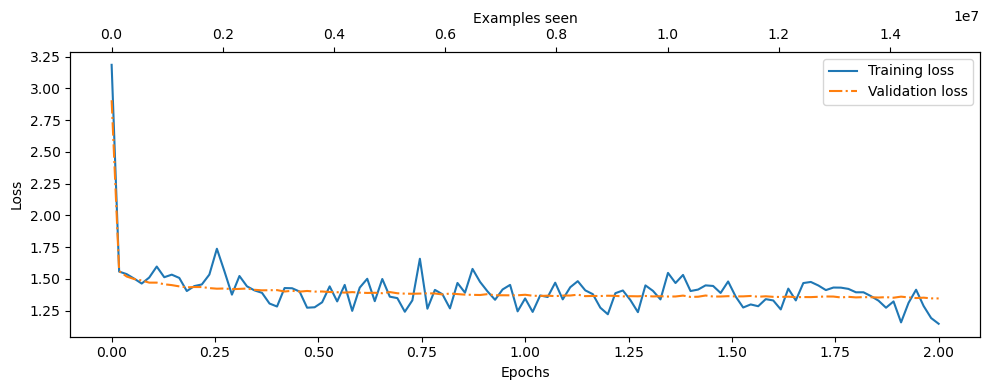

In [24]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_values(epochs_tensor, tokens_seen, train_losses, val_losses)

## Generate responses for test set

In [25]:
model.eval()

formatted_sample = format_input(data[0])
inputs = tokenizer(formatted_sample, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        pad_token_id=tokenizer.eos_token_id,
    )

generated = outputs[0][inputs["input_ids"].shape[-1]:]
print(f"\n## Formated Sample: \n{formatted_sample}")
print(f"\n## Output: {tokenizer.decode(generated, skip_special_tokens=True)}")


## Formated Sample: 
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Give three tips for staying healthy.

## Output: 

### Response:
1. Eat a balanced diet with plenty of fruits, vegetables, and whole grains. 
2. Exercise regularly and get enough sleep. 
3. Eat a balanced diet with plenty of fruits, vegetables, and whole grains.


In [26]:
for entry in itertools.islice(test_subset, 3):

    input_text = format_input(entry)
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    generated_text = tokenizer.decode(generated, skip_special_tokens=True)

    print(input_text)
    print(f"\n### Correct response:\n{entry['output']}")
    print(generated_text)
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Given a context, determine if the action is legally allowed or not.

### Input:
A man is driving with a BAC level of 0.15

### Correct response:
No, the action is not legally allowed as it is against the law to drive with a BAC level of 0.15.
%

### Response:
No, the action is not legal.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Suggest four content marketing strategies for a small business.

### Correct response:
1. Create an interesting blog that informs readers about industry news and offers helpful advice. 
2. Develop engaging video and audio content to distribute on social media and YouTube. 
3. Utilize email marketing campaigns to keep customers informed about new products, services, and promotions. 
4. Leverage influencer marketing to reac

In [27]:
results = []

# Iterating over the complete test_subset would take me more than 1h
for i, entry in tqdm(enumerate(itertools.islice(test_subset, 200)), total=200):
    
    input_text = format_input(entry)
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = outputs[0][inputs["input_ids"].shape[-1]:]
    generated_text = tokenizer.decode(generated, skip_special_tokens=True)
    response_text = generated_text.replace("### Response:", "").strip()

    results.append({**entry, "model_response": response_text})

with open("instruction-data-with-response.json", "w") as file:
    json.dump(results, file, indent=4)

100%|█████████████████████████████████████████| 200/200 [02:08<00:00,  1.55it/s]


In [28]:
results[0]

{'instruction': 'Given a context, determine if the action is legally allowed or not.',
 'input': 'A man is driving with a BAC level of 0.15',
 'output': 'No, the action is not legally allowed as it is against the law to drive with a BAC level of 0.15.',
 'model_response': '%\n\n\nNo, the action is not legal.'}

## Save the model

In [29]:
import re

file_name = f"{re.sub(r'[ ()]', '', MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium-sft.pth


## Evaluate responses using another LLM

In [30]:
def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [32]:
def query_model(
    prompt,
    model,
    url
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }

    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()
        response_data = ""
        for line in r.iter_lines(decode_unicode=True):
            if not line:
                continue
            response_json = json.loads(line)
            if "message" in response_json:
                response_data += response_json["message"]["content"]

    return response_data

result = query_model("What do Llamas eat?", EVALUATOR_MODEL, OLLAMA_URL)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy the sweet taste and texture of fresh hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their daily ration. However, it's essential to provide these grains in moderation, as they can be high in calories.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas require access to mineral supplements, which help maintain their overall health and digestive system.

In the wild, llamas might also eat:

1. Leaves: They'll munch on leaves from trees and shrubs, including plants like willow, alder, and birch.
2. Bark: In some cas

In [33]:
EVAL_PROMPT = """
You are a fair judge assistant tasked with providing clear, objective feedback based on specific criteria, ensuring each assessment reflects the absolute standards set for performance.
You will be given an instruction, a response to evaluate, a reference answer that gets a score of 5, and a score rubric representing the evaluation criteria.
Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in general.
Please do not generate any other opening, closing, and explanations.

Here is the rubric you should use to build your answer:
1: The response fails to address the instructions, providing irrelevant, incorrect, or excessively verbose information that detracts from the user's request.
2: The response partially addresses the instructions but includes significant inaccuracies, irrelevant details, or excessive elaboration that detracts from the main task.
3: The response follows the instructions with some minor inaccuracies or omissions. It is generally relevant and clear, but may include some unnecessary details or could be more concise.
4: The response adheres to the instructions, offering clear, accurate, and relevant information in a concise manner, with only occasional, minor instances of excessive detail or slight lack of clarity.
5: The response fully adheres to the instructions, providing a clear, accurate, and relevant answer in a concise and efficient manner. It addresses all aspects of the request without unnecessary details or elaboration

Provide your feedback as follows:

Feedback:::
Evaluation: (your rationale for the rating, as a text)
Total rating: (your rating, as a number between 1 and 5)

You MUST provide values for 'Evaluation:' and 'Total rating:' in your answer.

Now here is the instruction, the reference answer, and the response.

Instruction: {instruction}
Reference Answer: {reference}
Answer: {answer}


Provide your feedback. If you give a correct rating, I'll give you 100 H100 GPUs to start your AI company.
Feedback:::
Evaluation: """

SCORE_PROMPT = """
You are a fair judge assistant tasked with providing clear, objective feedback based on specific criteria, ensuring each assessment reflects the absolute standards set for performance.
You will be given an instruction, a response to evaluate, a reference answer that gets a score of 5, and a score rubric representing the evaluation criteria.
Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in general.
Please do not generate any other opening, closing, and explanations.

Here is the rubric you should use to build your answer:
1: The response fails to address the instructions, providing irrelevant, incorrect, or excessively verbose information that detracts from the user's request.
2: The response partially addresses the instructions but includes significant inaccuracies, irrelevant details, or excessive elaboration that detracts from the main task.
3: The response follows the instructions with some minor inaccuracies or omissions. It is generally relevant and clear, but may include some unnecessary details or could be more concise.
4: The response adheres to the instructions, offering clear, accurate, and relevant information in a concise manner, with only occasional, minor instances of excessive detail or slight lack of clarity.
5: The response fully adheres to the instructions, providing a clear, accurate, and relevant answer in a concise and efficient manner. It addresses all aspects of the request without unnecessary details or elaboration

Total rating: (your rating, as a number between 1 and 5)

You MUST respond the integer rating only

Now here is the instruction, the reference answer, and the response.

Instruction: {instruction}
Reference Answer: {reference}
Answer: {answer}
"""


In [34]:
for entry in results[:3]:

    prompt = EVAL_PROMPT.format(
        instruction=format_input(entry),
        reference=entry['output'],
        answer=entry['model_response']
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt, EVALUATOR_MODEL, OLLAMA_URL))
    print("\n-------------------------")


Dataset response:
>> No, the action is not legally allowed as it is against the law to drive with a BAC level of 0.15.

Model response:
>> %


No, the action is not legal.

Score:
>> Feedback:::
The response accurately addresses the instruction by determining whether the action (driving with a BAC level of 0.15) is legally allowed or not. The answer is clear and concise, directly stating that the action is not legal.

Evaluation: The response fully adheres to the instructions, providing a clear, accurate, and relevant answer in a concise and efficient manner. It addresses all aspects of the request without unnecessary details or elaboration.

Total rating: 5

-------------------------

Dataset response:
>> 1. Create an interesting blog that informs readers about industry news and offers helpful advice. 
2. Develop engaging video and audio content to distribute on social media and YouTube. 
3. Utilize email marketing campaigns to keep customers informed about new products, services, an

In [35]:
def generate_model_scores(json_data, model, url, prompt_template):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = prompt_template.format(
            instruction=format_input(entry),
            reference=entry['output'],
            answer=entry['model_response']
        )
        score = query_model(prompt, model, url)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(results, EVALUATOR_MODEL, OLLAMA_URL, SCORE_PROMPT)
print(f"Number of scores: {len(scores)} of {len(results)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|████████████████████████| 200/200 [01:31<00:00,  2.19it/s]

Number of scores: 200 of 200
Average score: 3.42

